# Entrega 2 — Detecção de Duplicatas

**Ouvidoria Inteligente: triagem semântica de manifestações cidadãs**

O sistema atual trata "asfalto esburacado" e "rua com buraco" como manifestações diferentes. Neste notebook, construímos a função `detectar_duplicatas(textos, limiar=0.85)`, que usa embeddings para encontrar pares de manifestações que descrevem o mesmo problema.

Etapas:

1. gerar os embeddings das 40 manifestações;
2. implementar a função de detecção;
3. visualizar a matriz de similaridade completa (heatmap);
4. estudar a distribuição das similaridades e **justificar o limiar**;
5. listar os pares encontrados;
6. comparar com as duplicatas reais do dataset (falsos positivos e falsos negativos).

In [1]:
# Bibliotecas (as variáveis de ambiente escondem barras de progresso e avisos do download dos modelos)
import json
import os

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_colwidth", 90)

## 1. Base e gabarito de duplicatas

Na base, cada duplicata real tem o campo `duplicata_de` apontando para a manifestação original. Esse é o gabarito usado para avaliar a função.

In [2]:
with open("manifestacoes.json", encoding="utf-8") as arquivo:
    manifestacoes = json.load(arquivo)

df = pd.DataFrame(manifestacoes)
textos = df["texto"].tolist()
ids = df["id"].tolist()

gabarito = {
    frozenset((m["id"], m["duplicata_de"])) for m in manifestacoes if m.get("duplicata_de")
}
print(f"Duplicatas reais no dataset: {len(gabarito)} pares")
df[df["duplicata_de"].notna()][["id", "duplicata_de", "categoria_oficial", "texto"]]

Duplicatas reais no dataset: 6 pares


,id,duplicata_de,categoria_oficial,texto
16,M017,M003,infraestrutura,O asfalto está todo esburacado na avenida principal. Tem uma cratera no meio da pista ...
21,M022,M008,saúde,Falta atendimento no PSF do Cristo. A unidade está sem doutor e a população volta sem ...
26,M027,M012,segurança,Roubos frequentes na parada de ônibus da Rua das Flores quando escurece. Levaram a bol...
28,M029,M010,educação,As crianças da escola municipal do Alto do Mateus estão sem alimentação. A merenda não...
32,M033,M019,meio ambiente,"Barulho do bar da Rua Silvino Lopes até tarde da noite, com música ao vivo em volume a..."
34,M035,M014,meio ambiente,"Entulho e resíduos jogados no lote vazio da Rua Duque de Caxias, no Centro. O lugar vi..."


## 2. Embeddings

Usamos o modelo multilíngue `paraphrase-multilingual-MiniLM-L12-v2`, o mesmo escolhido na Entrega 1. Os vetores são normalizados, então a similaridade de cosseno é o produto escalar entre eles.

In [3]:
NOME_MODELO = "paraphrase-multilingual-MiniLM-L12-v2"
modelo = SentenceTransformer(NOME_MODELO)

embeddings = modelo.encode(textos, normalize_embeddings=True)
matriz_sim = cosine_similarity(embeddings)
print(f"Embeddings: {embeddings.shape} · Matriz de similaridade: {matriz_sim.shape}")

Embeddings: (40, 384) · Matriz de similaridade: (40, 40)


## 3. Função `detectar_duplicatas`

A função recebe a lista de textos e o limiar e devolve todos os pares com similaridade **acima** do limiar, do mais parecido para o menos parecido. Cada par é comparado uma única vez (i < j), e um texto nunca é comparado com ele mesmo.

In [4]:
def detectar_duplicatas(textos, limiar=0.85):
    # Gera os embeddings normalizados e a matriz de similaridade de cosseno
    vetores = modelo.encode(textos, normalize_embeddings=True)
    similaridades = cosine_similarity(vetores)

    # Percorre só a metade de cima da matriz (i < j) para não repetir pares
    pares = []
    for i in range(len(textos)):
        for j in range(i + 1, len(textos)):
            if similaridades[i, j] > limiar:
                pares.append((i, j, float(similaridades[i, j])))

    return sorted(pares, key=lambda par: par[2], reverse=True)


def resumo(texto, limite=140):
    return texto if len(texto) <= limite else texto[:limite].rstrip() + "…"


def tabela_de_pares(pares):
    linhas = []
    for i, j, score in pares:
        linhas.append({
            "Manifestação A": ids[i],
            "Manifestação B": ids[j],
            "Similaridade": score,
            "Duplicata real?": "✅ sim" if frozenset((ids[i], ids[j])) in gabarito else "❌ não",
            "Texto A": resumo(textos[i]),
            "Texto B": resumo(textos[j]),
        })
    return pd.DataFrame(linhas)

## 4. Matriz de similaridade completa

Os quadrados verdes marcam as duplicatas reais do gabarito. Uma boa representação deve deixar essas células mais claras (mais similares) que o restante da linha.

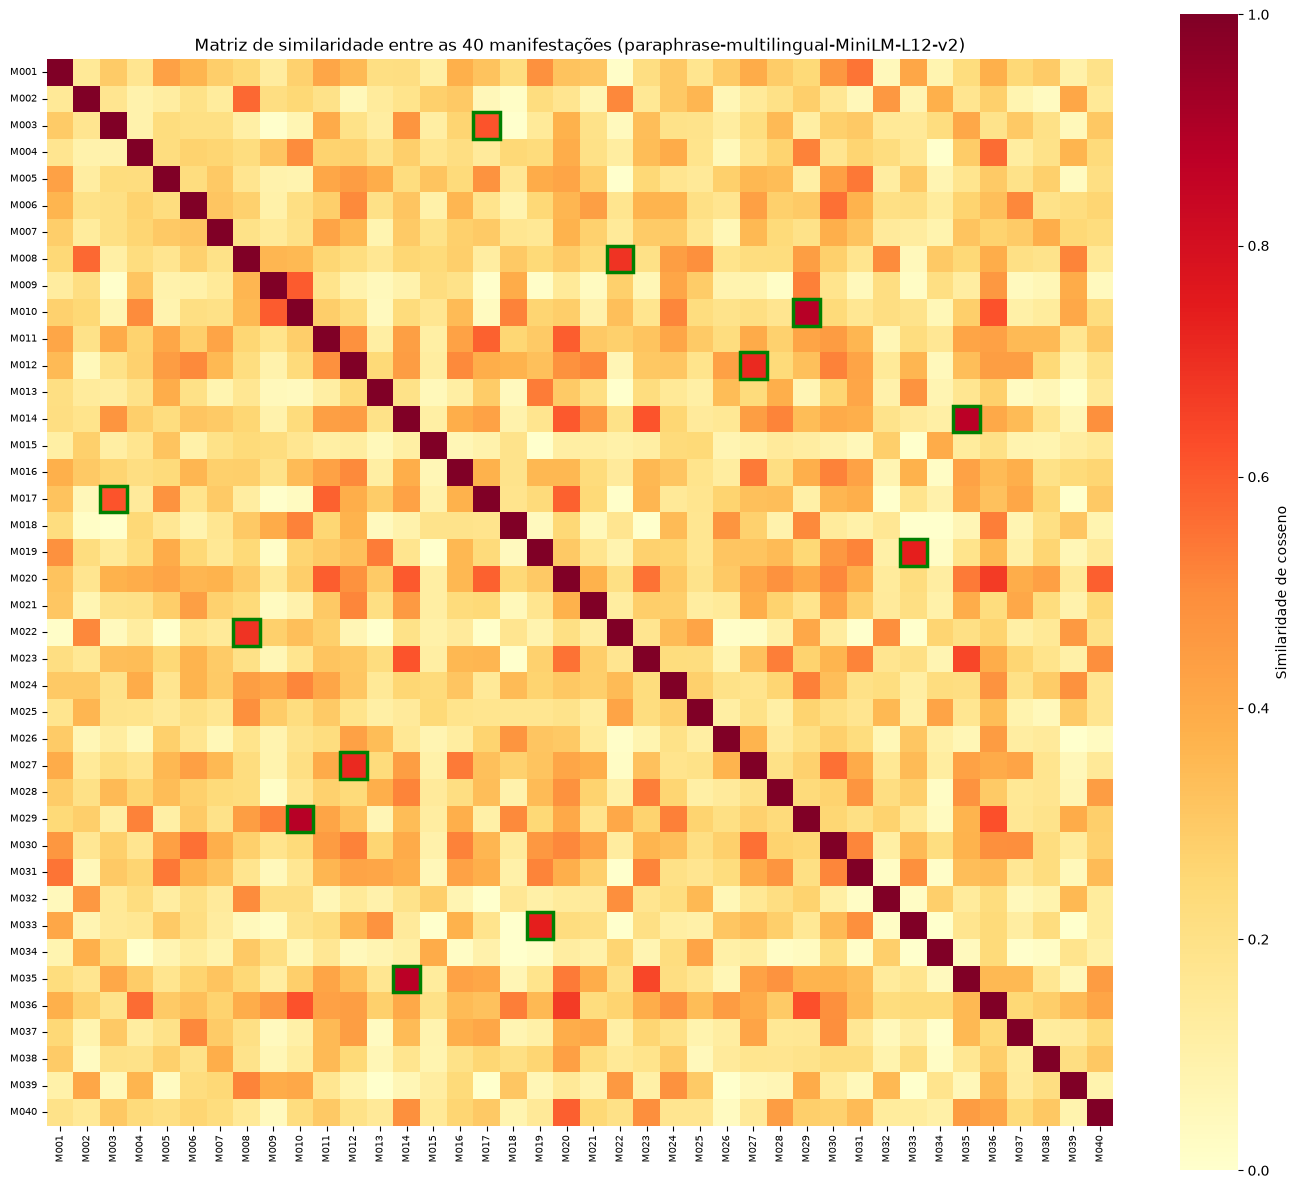

In [5]:
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(matriz_sim, xticklabels=ids, yticklabels=ids, cmap="YlOrRd", vmin=0, vmax=1,
            square=True, cbar_kws={"label": "Similaridade de cosseno"}, ax=ax)

for par in gabarito:
    a, b = sorted(ids.index(x) for x in par)
    for linha, coluna in [(a, b), (b, a)]:
        ax.add_patch(plt.Rectangle((coluna, linha), 1, 1, fill=False, edgecolor="green", lw=2.5))

ax.set_title(f"Matriz de similaridade entre as 40 manifestações ({NOME_MODELO})")
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

## 5. Escolha do limiar

O limiar sugerido de 0,85 é só um ponto de partida: a escala da similaridade muda de um modelo para outro. Para escolher um valor justificado, analisamos:

1. **a distribuição** das similaridades de todos os 780 pares, destacando onde caem as duplicatas reais;
2. **uma varredura de limiares**, medindo precisão, revocação e F1 em relação ao gabarito;
3. **um limiar dinâmico**, baseado em percentis da distribuição, como sugere o enunciado.

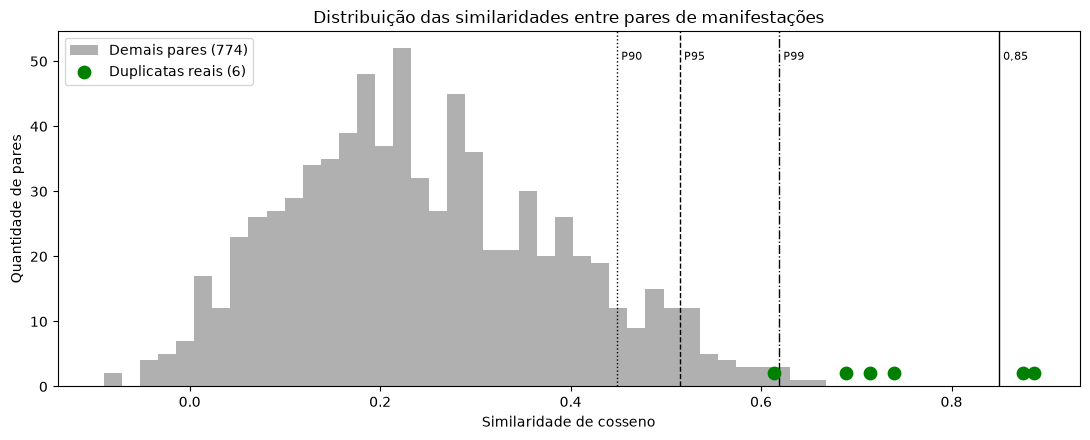

Duplicatas reais: mínima 0.613 · média 0.753 · máxima 0.886
Demais pares:     média 0.246 · máxima 0.668
Percentis de todos os pares: P90 = 0.449 · P95 = 0.515 · P99 = 0.619


In [6]:
# Similaridades de todos os pares únicos (metade de cima da matriz)
todos = [(i, j, matriz_sim[i, j]) for i in range(len(ids)) for j in range(i + 1, len(ids))]
sim_dup = [s for i, j, s in todos if frozenset((ids[i], ids[j])) in gabarito]
sim_outros = [s for i, j, s in todos if frozenset((ids[i], ids[j])) not in gabarito]

p90, p95, p99 = np.percentile([s for _, _, s in todos], [90, 95, 99])

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(sim_outros, bins=40, color="#b0b0b0", label=f"Demais pares ({len(sim_outros)})")
ax.scatter(sim_dup, np.full(len(sim_dup), 2), color="green", s=80, zorder=3,
           label=f"Duplicatas reais ({len(sim_dup)})")
for valor, nome, estilo in [(p90, "P90", ":"), (p95, "P95", "--"), (p99, "P99", "-."), (0.85, "0,85", "-")]:
    ax.axvline(valor, color="black", linestyle=estilo, lw=1)
    ax.text(valor, ax.get_ylim()[1] * 0.92, f" {nome}", fontsize=8)
ax.set_xlabel("Similaridade de cosseno")
ax.set_ylabel("Quantidade de pares")
ax.set_title("Distribuição das similaridades entre pares de manifestações")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Duplicatas reais: mínima {min(sim_dup):.3f} · média {np.mean(sim_dup):.3f} · máxima {max(sim_dup):.3f}")
print(f"Demais pares:     média {np.mean(sim_outros):.3f} · máxima {max(sim_outros):.3f}")
print(f"Percentis de todos os pares: P90 = {p90:.3f} · P95 = {p95:.3f} · P99 = {p99:.3f}")

In [7]:
def avaliar(limiar):
    encontrados = {frozenset((ids[i], ids[j])) for i, j, s in todos if s > limiar}
    vp = len(encontrados & gabarito)
    fp = len(encontrados - gabarito)
    fn = len(gabarito - encontrados)
    precisao = vp / (vp + fp) if vp + fp else 0.0
    revocacao = vp / (vp + fn) if vp + fn else 0.0
    f1 = 2 * precisao * revocacao / (precisao + revocacao) if precisao + revocacao else 0.0
    return {"Limiar": limiar, "Pares encontrados": vp + fp, "VP": vp, "FP": fp, "FN": fn,
            "Precisão": precisao, "Revocação": revocacao, "F1": f1}


limiares = [round(x, 2) for x in np.arange(0.50, 0.96, 0.05)] + [round(p90, 3), round(p95, 3), round(p99, 3)]
varredura = pd.DataFrame([avaliar(l) for l in sorted(set(limiares))])
varredura.style.format({"Limiar": "{:.3f}", "Precisão": "{:.2f}", "Revocação": "{:.2f}", "F1": "{:.2f}"}).background_gradient(
    cmap="Greens", subset=["F1"])

,Limiar,Pares encontrados,VP,FP,FN,Precisão,Revocação,F1
0,0.449,78,6,72,0,0.08,1.00,0.14
1,0.500,50,6,44,0,0.12,1.00,0.21
2,0.515,39,6,33,0,0.15,1.00,0.27
3,0.550,22,6,16,0,0.27,1.00,0.43
4,0.600,13,6,7,0,0.46,1.00,0.63
5,0.619,8,5,3,1,0.62,0.83,0.71
6,0.650,6,5,1,1,0.83,0.83,0.83
7,0.700,4,4,0,2,1.00,0.67,0.80
8,0.750,2,2,0,4,1.00,0.33,0.50
9,0.800,2,2,0,4,1.00,0.33,0.50


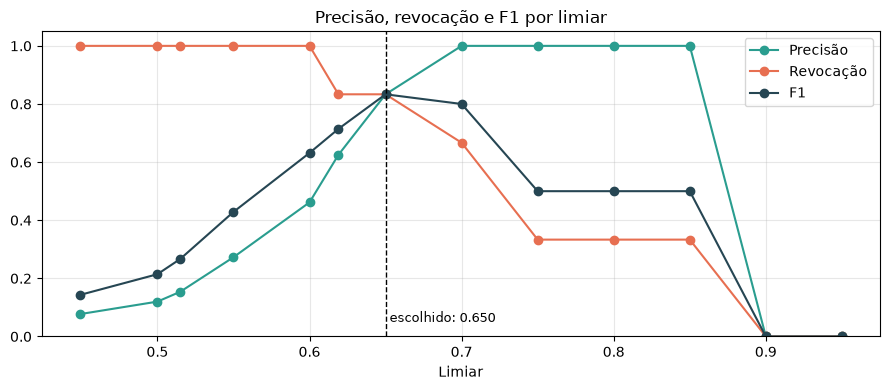

Limiar escolhido: 0.650 (F1 = 0.83, precisão = 0.83, revocação = 0.83)


In [8]:
# Limiar escolhido: o de maior F1; em caso de empate, o mais alto (menos falsos positivos)
melhor = varredura.sort_values(["F1", "Limiar"], ascending=[False, False]).iloc[0]
LIMIAR_ESCOLHIDO = float(melhor["Limiar"])

fig, ax = plt.subplots(figsize=(9, 4))
for coluna, cor in [("Precisão", "#2a9d8f"), ("Revocação", "#e76f51"), ("F1", "#264653")]:
    ax.plot(varredura["Limiar"], varredura[coluna], marker="o", label=coluna, color=cor)
ax.axvline(LIMIAR_ESCOLHIDO, color="black", linestyle="--", lw=1)
ax.text(LIMIAR_ESCOLHIDO, 0.05, f" escolhido: {LIMIAR_ESCOLHIDO:.3f}", fontsize=9)
ax.set_xlabel("Limiar")
ax.set_ylim(0, 1.05)
ax.set_title("Precisão, revocação e F1 por limiar")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Limiar escolhido: {LIMIAR_ESCOLHIDO:.3f} (F1 = {melhor['F1']:.2f}, "
      f"precisão = {melhor['Precisão']:.2f}, revocação = {melhor['Revocação']:.2f})")

## 6. Pares duplicados encontrados

Primeiro com o limiar padrão da função (0,85) e depois com o limiar escolhido pela análise.

In [9]:
pares_padrao = detectar_duplicatas(textos)
print(f"Limiar 0,85 → {len(pares_padrao)} par(es) encontrado(s)")
tabela_de_pares(pares_padrao)

Limiar 0,85 → 2 par(es) encontrado(s)


,Manifestação A,Manifestação B,Similaridade,Duplicata real?,Texto A,Texto B
0,M010,M029,0.886132,✅ sim,Na escola municipal do bairro Alto do Mateus não está sendo servida merenda escolar há...,As crianças da escola municipal do Alto do Mateus estão sem alimentação. A merenda não...
1,M014,M035,0.875449,✅ sim,"Há muito lixo acumulado no terreno baldio da Rua Duque de Caxias, no Centro. Está junt...","Entulho e resíduos jogados no lote vazio da Rua Duque de Caxias, no Centro. O lugar vi..."


In [10]:
pares_escolhidos = detectar_duplicatas(textos, limiar=LIMIAR_ESCOLHIDO)
print(f"Limiar {LIMIAR_ESCOLHIDO:.3f} → {len(pares_escolhidos)} par(es) encontrado(s)")
tabela_de_pares(pares_escolhidos).style.format({"Similaridade": "{:.3f}"})

Limiar 0.650 → 6 par(es) encontrado(s)


,Manifestação A,Manifestação B,Similaridade,Duplicata real?,Texto A,Texto B
0,M010,M029,0.886,✅ sim,Na escola municipal do bairro Alto do Mateus não está sendo servida merenda escolar há uma semana. As crianças ficam com fome até o fim da a…,As crianças da escola municipal do Alto do Mateus estão sem alimentação. A merenda não chega há dias e os alunos voltam para casa com fome.
1,M014,M035,0.875,✅ sim,"Há muito lixo acumulado no terreno baldio da Rua Duque de Caxias, no Centro. Está juntando rato e mosquito.","Entulho e resíduos jogados no lote vazio da Rua Duque de Caxias, no Centro. O lugar virou um lixão com ratos."
2,M019,M033,0.739,✅ sim,"O bar da esquina da Rua Silvino Lopes fica com som alto até de madrugada, todos os dias. Ninguém consegue dormir.","Barulho do bar da Rua Silvino Lopes até tarde da noite, com música ao vivo em volume absurdo, toda semana."
3,M012,M027,0.714,✅ sim,Estão acontecendo muitos assaltos no ponto de ônibus da Rua das Flores à noite. Já roubaram celular de três vizinhos.,Roubos frequentes na parada de ônibus da Rua das Flores quando escurece. Levaram a bolsa da minha esposa na terça-feira.
4,M008,M022,0.689,✅ sim,O posto de saúde do bairro Cristo está sem médico desde o começo do mês. As pessoas chegam cedo e voltam para casa sem consulta.,"Falta atendimento no PSF do Cristo. A unidade está sem doutor e a população volta sem ser atendida, só fazem curativo."
5,M020,M036,0.668,❌ não,"Venho, mais uma vez, registrar a situação da Rua Projetada 12, no bairro Gramame. Sempre que chove forte a rua inteira alaga, porque não exi…",Sou mãe de dois alunos da escola municipal do bairro Gramame e preciso relatar vários problemas. O transporte escolar atrasa quase todos os…


## 7. Falsos positivos e falsos negativos

- **Falso positivo (FP):** a função apontou como duplicata, mas não é.
- **Falso negativo (FN):** é duplicata no gabarito, mas a função não encontrou.

In [11]:
encontrados = {frozenset((ids[i], ids[j])): s for i, j, s in pares_escolhidos}

falsos_positivos = [(sorted(p), s) for p, s in encontrados.items() if p not in gabarito]
falsos_negativos = [sorted(p) for p in gabarito if p not in encontrados]

print(f"Falsos positivos: {len(falsos_positivos)}")
for (a, b), s in sorted(falsos_positivos, key=lambda x: -x[1]):
    print(f"  {a} × {b} (sim = {s:.3f})")
    print(f"    {a}: {resumo(textos[ids.index(a)])}")
    print(f"    {b}: {resumo(textos[ids.index(b)])}")

print(f"\nFalsos negativos: {len(falsos_negativos)}")
for a, b in falsos_negativos:
    s = matriz_sim[ids.index(a), ids.index(b)]
    print(f"  {a} × {b} (sim = {s:.3f})")
    print(f"    {a}: {resumo(textos[ids.index(a)])}")
    print(f"    {b}: {resumo(textos[ids.index(b)])}")

Falsos positivos: 1
  M020 × M036 (sim = 0.668)
    M020: Venho, mais uma vez, registrar a situação da Rua Projetada 12, no bairro Gramame. Sempre que chove forte a rua inteira alaga, porque não exi…
    M036: Sou mãe de dois alunos da escola municipal do bairro Gramame e preciso relatar vários problemas. O transporte escolar atrasa quase todos os…

Falsos negativos: 1
  M003 × M017 (sim = 0.613)
    M003: Tem um buraco enorme na Av. Brasil, perto do mercado. Já vi duas motos caírem nele esta semana.
    M017: O asfalto está todo esburacado na avenida principal. Tem uma cratera no meio da pista que já derrubou motociclistas e estraga os pneus dos c…


## 8. Pares que mais confundem o modelo

Os "vizinhos difíceis" são pares que **não** são duplicatas, mas têm similaridade alta. Eles mostram onde um limiar mais baixo começaria a errar.

In [12]:
vizinhos = sorted(
    [(ids[i], ids[j], s) for i, j, s in todos if frozenset((ids[i], ids[j])) not in gabarito],
    key=lambda x: -x[2],
)[:8]
pd.DataFrame(
    [{"A": a, "B": b, "Similaridade": s, "Texto A": resumo(textos[ids.index(a)]), "Texto B": resumo(textos[ids.index(b)])}
     for a, b, s in vizinhos]
).style.format({"Similaridade": "{:.3f}"})

,A,B,Similaridade,Texto A,Texto B
0,M020,M036,0.668,"Venho, mais uma vez, registrar a situação da Rua Projetada 12, no bairro Gramame. Sempre que chove forte a rua inteira alaga, porque não exi…",Sou mãe de dois alunos da escola municipal do bairro Gramame e preciso relatar vários problemas. O transporte escolar atrasa quase todos os…
1,M023,M035,0.643,"A queimada de lixo no terreno ao lado da minha casa, no bairro Costa e Silva, está deixando a fumaça entrar em todos os cômodos.","Entulho e resíduos jogados no lote vazio da Rua Duque de Caxias, no Centro. O lugar virou um lixão com ratos."
2,M029,M036,0.623,As crianças da escola municipal do Alto do Mateus estão sem alimentação. A merenda não chega há dias e os alunos voltam para casa com fome.,Sou mãe de dois alunos da escola municipal do bairro Gramame e preciso relatar vários problemas. O transporte escolar atrasa quase todos os…
3,M010,M036,0.618,Na escola municipal do bairro Alto do Mateus não está sendo servida merenda escolar há uma semana. As crianças ficam com fome até o fim da a…,Sou mãe de dois alunos da escola municipal do bairro Gramame e preciso relatar vários problemas. O transporte escolar atrasa quase todos os…
4,M014,M023,0.616,"Há muito lixo acumulado no terreno baldio da Rua Duque de Caxias, no Centro. Está juntando rato e mosquito.","A queimada de lixo no terreno ao lado da minha casa, no bairro Costa e Silva, está deixando a fumaça entrar em todos os cômodos."
5,M014,M020,0.603,"Há muito lixo acumulado no terreno baldio da Rua Duque de Caxias, no Centro. Está juntando rato e mosquito.","Venho, mais uma vez, registrar a situação da Rua Projetada 12, no bairro Gramame. Sempre que chove forte a rua inteira alaga, porque não exi…"
6,M009,M010,0.601,Meu filho está sem professor de matemática desde fevereiro na escola municipal do bairro Cruz das Armas.,Na escola municipal do bairro Alto do Mateus não está sendo servida merenda escolar há uma semana. As crianças ficam com fome até o fim da a…
7,M011,M020,0.594,"A calçada da Rua da Areia está toda quebrada, com pedras soltas. Idosos e cadeirantes não conseguem passar.","Venho, mais uma vez, registrar a situação da Rua Projetada 12, no bairro Gramame. Sempre que chove forte a rua inteira alaga, porque não exi…"


## 9. Conclusão

A função `detectar_duplicatas` usa embeddings para comparar o significado das manifestações. Por isso, reconhece relatos do mesmo problema mesmo quando eles não compartilham palavras, o que era a falha do sistema por palavras-chave.

**Sobre o limiar.** Com o limiar padrão de 0,85, a função encontrou só 2 das 6 duplicatas (precisão de 100%, revocação de 33%). Nesse modelo, as duplicatas reais ficam entre 0,613 e 0,886, então 0,85 é rígido demais. A varredura mostra o equilíbrio entre os dois tipos de erro: até 0,60 todas as duplicatas são encontradas, mas junto com 7 a 72 pares errados, e a partir de 0,70 não há mais falsos positivos, mas as duplicatas começam a escapar. O limiar escolhido foi **0,65**, o de maior F1 (0,83), com 5 acertos, 1 falso positivo e 1 falso negativo. O limiar dinâmico pelo percentil 99 (0,619) chega perto (F1 de 0,71) e é uma boa alternativa quando não há gabarito para calibrar. Não existe limiar perfeito nesta base: a duplicata menos parecida (0,613) fica abaixo do par não duplicado mais parecido (0,668), então as duas distribuições se sobrepõem.

**Falso positivo: M020 × M036 (0,668).** São as duas manifestações longas do bairro Gramame. Uma trata de alagamento na rua e a outra de problemas na escola, mas as duas dizem que, com a chuva, a estrada vira lama e o ônibus (ou o transporte escolar) deixa de passar. O modelo resume cada texto longo num único vetor e acaba aproximando os dois por esse trecho em comum. Isso mostra, na prática, o problema dos textos longos que motiva a Entrega 3: indexados como um bloco só, eles viram uma "média" de vários assuntos. A tabela da seção 8 reforça esse ponto, já que M036 aparece em três dos oito pares não duplicados mais parecidos.

**Falso negativo: M003 × M017 (0,613).** É o mesmo buraco descrito com vocabulário totalmente diferente ("buraco" × "asfalto esburacado", "cratera"), e M017 não cita a Av. Brasil. É o caso mais difícil da base, e o modelo ainda deu 0,613, bem acima da média dos pares não duplicados (0,246), mas não o bastante para passar do limiar.

**Na prática,** o sistema deve **sugerir** possíveis duplicatas para um atendente confirmar, e não juntá-las automaticamente: com qualquer limiar, sempre sobra algum erro de um dos dois tipos.